# LAB 3.2 - Echo State Networks

Model selection and final evaluation for ESN on NARMA10.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

import yaml
import numpy as np
import torch

from esn import ESNParams, EchoStateNetwork
from search import random_search_esn
from utils_esn import (
    load_narma10,
    plot_predictions,
    plot_series,
    reshape_for_esn,
    split_series,
)


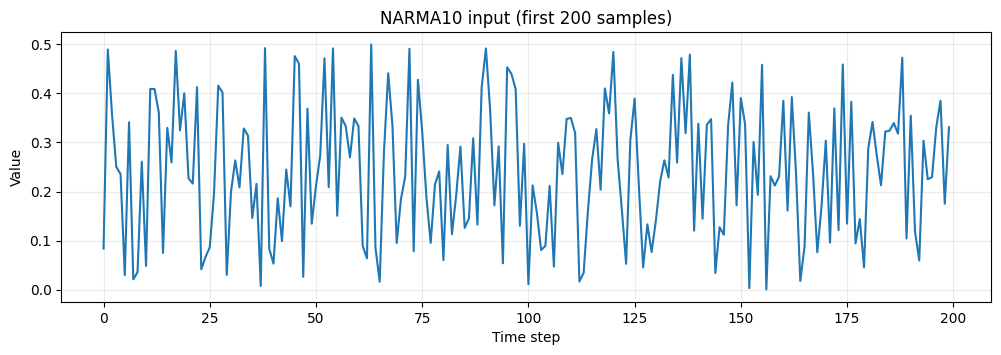

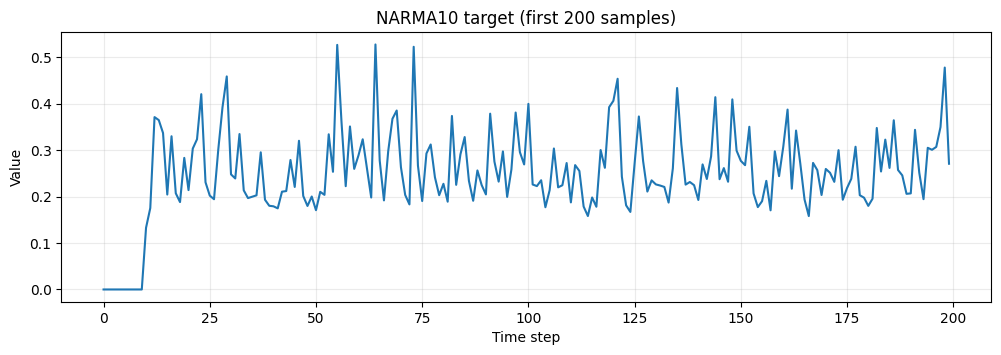

In [2]:
x, y = load_narma10(PROJECT_ROOT / "data" / "NARMA10.csv")
plot_series(x, "NARMA10 input (first 200 samples)")
plot_series(y, "NARMA10 target (first 200 samples)")

x_train, x_val, x_test, y_train, y_val, y_test = split_series(x, y, train_size=4000, val_size=1000)
x_train, x_val, x_test, y_train, y_val, y_test = reshape_for_esn(
    (x_train, x_val, x_test), (y_train, y_val, y_test)
)


In [3]:
with open(PROJECT_ROOT / "configs" / "esn.yaml", "r", encoding="utf-8") as fp:
    esn_space = yaml.safe_load(fp)

random_iter = 500
n_runs = 5

best = random_search_esn(
    space=esn_space,
    random_iter=random_iter,
    n_runs=n_runs,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    seed=42,
)

print("Best trial:", best["trial"])
print("Best params:")
for k, v in best["params"].items():
    print(f"  {k}: {v}")

print(f"Train MSE: {best['train_mean']:.8f} +/- {best['train_std']:.8f}")
print(f"Val   MSE: {best['val_mean']:.8f} +/- {best['val_std']:.8f}")


Best trial: 201
Best params:
  hidden_dim: 1024
  l2: 0.1
  spectral_radius: 0.99
  input_scale: 25
  bias_scale: 0.01
  scale_mode: norm
  washout: 512
Train MSE: 0.00017375 +/- 0.00001679
Val   MSE: 0.00018814 +/- 0.00002544


In [4]:
x_re = torch.tensor(np.concatenate([x_train.numpy(), x_val.numpy()], axis=0), dtype=torch.float32)
y_re = torch.tensor(np.concatenate([y_train.numpy(), y_val.numpy()], axis=0), dtype=torch.float32)

params = best["params"]
retrain_losses = []
test_losses = []
final_model = None

for run in range(5):
    esn_params = ESNParams(
        input_dim=1,
        output_dim=1,
        hidden_dim=int(params["hidden_dim"]),
        spectral_radius=float(params["spectral_radius"]),
        input_scale=float(params["input_scale"]),
        bias_scale=float(params["bias_scale"]),
        scale_mode=str(params["scale_mode"]),
        washout=int(params["washout"]),
        seed=100 + run,
    )

    model = EchoStateNetwork(esn_params)
    model.fit(x_re, y_re, l2=float(params["l2"]))

    y_re_hat = model.predict(x_re)
    y_test_hat = model.predict(x_test)

    retrain_losses.append(float(model.mse(y_re, y_re_hat).item()))
    test_losses.append(float(model.mse(y_test, y_test_hat).item()))
    final_model = model

print(f"Retrain MSE: {np.mean(retrain_losses):.8f} +/- {np.std(retrain_losses):.8f}")
print(f"Test    MSE: {np.mean(test_losses):.8f} +/- {np.std(test_losses):.8f}")


Retrain MSE: 0.00017533 +/- 0.00001755
Test    MSE: 0.00011468 +/- 0.00001397


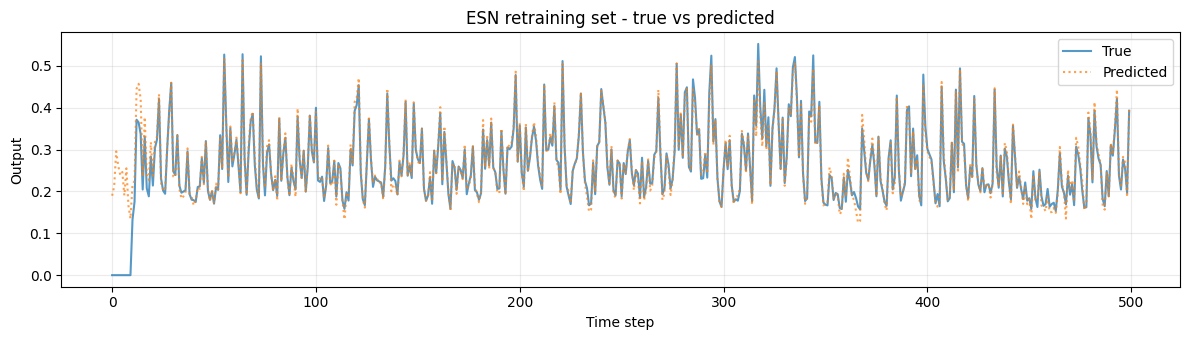

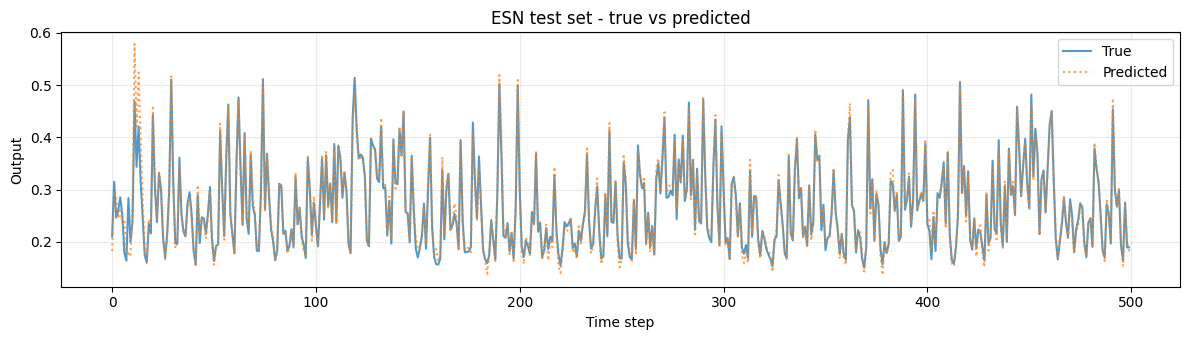

In [5]:
y_re_hat = final_model.predict(x_re)
y_test_hat = final_model.predict(x_test)

plot_predictions(
    y_re,
    y_re_hat,
    title="ESN retraining set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "esn_retrain_predictions.png",
    start=0,
    end=500,
)
plot_predictions(
    y_test,
    y_test_hat,
    title="ESN test set - true vs predicted",
    path=PROJECT_ROOT / "figures" / "esn_test_predictions.png",
    start=0,
    end=500,
)


In [6]:
summary_path = PROJECT_ROOT / "results" / "best_model_summary.txt"
summary_path.parent.mkdir(parents=True, exist_ok=True)

with open(summary_path, "w", encoding="utf-8") as fp:
    fp.write("ESN Best Configuration\n")
    fp.write("======================\n\n")
    fp.write(f"Search trial: {best['trial']}\n")
    fp.write(f"Train MSE: {best['train_mean']:.8f} +/- {best['train_std']:.8f}\n")
    fp.write(f"Val MSE: {best['val_mean']:.8f} +/- {best['val_std']:.8f}\n")
    fp.write(f"Retrain MSE: {np.mean(retrain_losses):.8f} +/- {np.std(retrain_losses):.8f}\n")
    fp.write(f"Test MSE: {np.mean(test_losses):.8f} +/- {np.std(test_losses):.8f}\n\n")

    fp.write("Hyperparameters\n")
    fp.write("---------------\n")
    for k, v in best["params"].items():
        fp.write(f"{k}: {v}\n")

    fp.write("\nParameter tensor shapes\n")
    fp.write("-----------------------\n")
    for name, tensor in final_model.export_parameters().items():
        fp.write(f"{name}: {tuple(tensor.shape)}\n")

print(f"Summary written to: {summary_path}")


Summary written to: /Users/roberto/Developer/CNS/cns_lab_new/LAB3-20260216/solutions/lab3_2/results/best_model_summary.txt
